# Machine Learning 741 — Assignment 3
## Option 4: Time Series Forecasting using Recurrent Neural Networks

This notebook contains the complete experiment for the five time-series datasets. The flow is kept simple: load and preprocess the data, check stationarity, define chronological cross-validation, train the three recurrent networks, select settings using validation data, and evaluate the fixed models on the held-out test period.

Running **Run All** performs the real experiment.


## 1. Imports and experiment settings

All datasets are represented hourly and use the previous 24 hours to predict the next value. The first 80% of each series is used for development and the final 20% is held out for testing. Hyperparameters are selected using three expanding chronological folds.


In [1]:
from pathlib import Path
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.tsa.stattools import adfuller, kpss

RANDOM_STATE = 11
WINDOW = 24
DEVELOPMENT_FRACTION = 0.80
CV_FOLDS = 3

HIDDEN_SIZES = [4, 8]
LEARNING_RATES = [0.003, 0.01]

MAX_EPOCHS = 40
PATIENCE = 8
BATCH_SIZE = 32
L2 = 1e-4
MAX_TRAIN_WINDOWS = 1200

FINAL_SEEDS = [11, 29, 47]
NETWORKS = ["elman", "jordan", "multi"]

PERSISTENCE_BASELINE = "Persistence baseline"
SEASONAL_BASELINE = "24-hour seasonal-naive baseline"

OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Results folder:", OUTPUT_DIR.resolve())


Results folder: /home/james/CS741-Assignments/Assignment3/src/results


## 2. Load the datasets

The notebook searches a `data/` folder beside the notebook, the current working directory, and `/mnt/data`. Both normal filenames and `(1)` download variants are accepted.


In [2]:
FILE_OPTIONS = {
    "Metro Traffic": [
        "Metro_Interstate_Traffic_Volume.csv",
        "Metro_Interstate_Traffic_Volume(1).csv",
    ],
    "Household Power": [
        "household_power_consumption.txt",
        "household_power_consumption(1).txt",
    ],
    "Beijing Air Quality": [
        "PRSA_Data_Wanliu_20130301-20170228.csv",
        "PRSA_Data_Wanliu_20130301-20170228(1).csv",
    ],
    "Appliances Energy": [
        "energydata_complete.csv",
        "energydata_complete(1).csv",
    ],
    "Bike Sharing": [
        "hour.csv",
        "hour(1).csv",
    ],
}


def search_directories():
    folders = [Path.cwd() / "data", Path.cwd(), Path("/mnt/data")]
    return list(dict.fromkeys(folders))


def find_file(names):
    for folder in search_directories():
        for name in names:
            path = folder / name
            if path.is_file():
                return path

    expected = ", ".join(names)
    searched = "\n".join(f"  - {folder.resolve()}" for folder in search_directories())
    raise FileNotFoundError(f"Could not find any of: {expected}\nSearched:\n{searched}")


DATA_PATHS = {
    dataset: find_file(names)
    for dataset, names in FILE_OPTIONS.items()
}

print("Found all five dataset files.")


Found all five dataset files.


## 3. Preprocess the time series

Each dataset is converted to one hourly target series. Missing timestamps are kept on a regular hourly index and forward-filled only to maintain continuity. The `observed` mask prevents filled values from being used as model inputs or targets.


In [3]:
def make_hourly_series(name, times, values, target, aggregation="mean"):
    frame = pd.DataFrame({
        "time": pd.to_datetime(times),
        "value": pd.to_numeric(values, errors="coerce"),
    })

    frame["time"] = frame["time"].dt.floor("h")
    grouped = frame.groupby("time")["value"]
    hourly = grouped.sum(min_count=1) if aggregation == "sum" else grouped.mean()

    full_index = pd.date_range(hourly.index.min(), hourly.index.max(), freq="h")
    hourly = hourly.reindex(full_index)

    first_valid = hourly.first_valid_index()
    if first_valid is None:
        raise ValueError(f"{name} contains no valid target values.")

    hourly = hourly.loc[first_valid:]
    observed = hourly.notna().to_numpy()
    hourly = hourly.ffill()

    return {
        "name": name,
        "target": target,
        "time": hourly.index.to_numpy(),
        "y": hourly.to_numpy(dtype=float),
        "observed": observed,
    }


metro = pd.read_csv(
    DATA_PATHS["Metro Traffic"],
    usecols=["date_time", "traffic_volume"],
)
traffic = make_hourly_series(
    "metro_traffic", metro["date_time"], metro["traffic_volume"], "traffic_volume"
)

power = pd.read_csv(
    DATA_PATHS["Household Power"],
    sep=";",
    usecols=["Date", "Time", "Global_active_power"],
    na_values="?",
    low_memory=False,
)
power_time = pd.to_datetime(
    power["Date"] + " " + power["Time"],
    format="%d/%m/%Y %H:%M:%S",
)
household = make_hourly_series(
    "household_power", power_time, power["Global_active_power"], "Global_active_power"
)

air = pd.read_csv(
    DATA_PATHS["Beijing Air Quality"],
    usecols=["year", "month", "day", "hour", "PM2.5", "station"],
)
assert set(air["station"].dropna().unique()) == {"Wanliu"}
air_time = pd.to_datetime(air[["year", "month", "day", "hour"]])
beijing = make_hourly_series(
    "beijing_wanliu_pm25", air_time, air["PM2.5"], "PM2.5"
)

energy = pd.read_csv(
    DATA_PATHS["Appliances Energy"],
    usecols=["date", "Appliances"],
)
appliances = make_hourly_series(
    "appliances_energy", energy["date"], energy["Appliances"], "Appliances"
)

bike = pd.read_csv(
    DATA_PATHS["Bike Sharing"],
    usecols=["dteday", "hr", "cnt"],
)
bike_time = pd.to_datetime(bike["dteday"]) + pd.to_timedelta(bike["hr"], unit="h")
cycling = make_hourly_series(
    "bike_sharing", bike_time, bike["cnt"], "cnt", aggregation="sum"
)

DATASETS = [traffic, household, beijing, appliances, cycling]

assert len(DATASETS) == 5
assert len({dataset["name"] for dataset in DATASETS}) == 5
print("Loaded all five datasets successfully.")


Loaded all five datasets successfully.


## 4. Dataset summary and stationarity

Only information needed for the experiment is retained here: series length, missing hourly positions, time range, and stationarity. ADF and KPSS are calculated from genuinely observed values in the development period only.

A series is labelled **Stationary** when ADF rejects a unit root at 5% and KPSS does not reject trend stationarity at 5%. If the tests disagree, the series is labelled **Non-stationary** conservatively.


In [4]:
def development_end(dataset):
    return int(DEVELOPMENT_FRACTION * len(dataset["y"]))


summary_rows = []

for dataset in DATASETS:
    end = development_end(dataset)
    observed = dataset["observed"][:end]
    values = dataset["y"][:end][observed]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        adf_p = float(adfuller(values, autolag="AIC")[1])
        kpss_p = float(kpss(values, regression="ct", nlags="auto")[1])

    stationarity = (
        "Stationary"
        if adf_p < 0.05 and kpss_p >= 0.05
        else "Non-stationary"
    )

    summary_rows.append({
        "dataset": dataset["name"],
        "target": dataset["target"],
        "hourly_rows": len(dataset["y"]),
        "missing_hours": int((~dataset["observed"]).sum()),
        "start": str(dataset["time"][0]),
        "end": str(dataset["time"][-1]),
        "adf_p": adf_p,
        "kpss_p": kpss_p,
        "stationarity": stationarity,
    })


dataset_summary = pd.DataFrame(summary_rows)
display(dataset_summary.round({"adf_p": 5, "kpss_p": 5}))


,dataset,target,hourly_rows,missing_hours,start,end,adf_p,kpss_p,stationarity
0,metro_traffic,traffic_volume,52551,11976,2012-10-02T09:00:00.000000000,2018-09-30T23:00:00.000000000,0.0,0.03689,Non-stationary
1,household_power,Global_active_power,34589,421,2006-12-16T17:00:00.000000000,2010-11-26T21:00:00.000000000,0.0,0.01000,Non-stationary
2,beijing_wanliu_pm25,PM2.5,35064,382,2013-03-01T00:00:00.000000000,2017-02-28T23:00:00.000000000,0.0,0.10000,Stationary
3,appliances_energy,Appliances,3290,0,2016-01-11T17:00:00.000000000,2016-05-27T18:00:00.000000000,0.0,0.10000,Stationary
4,bike_sharing,cnt,17544,165,2011-01-01T00:00:00.000000000,2012-12-31T23:00:00.000000000,0.0,0.01000,Non-stationary


## 5. Time-series cross-validation

The final 20% of each series is kept untouched for testing. Inside the first 80%, three expanding chronological folds are used so that every validation block occurs after its training block.


In [5]:
def make_cv_folds(n):
    dev_end = int(DEVELOPMENT_FRACTION * n)
    edges = np.linspace(
        int(0.5 * dev_end),
        dev_end,
        CV_FOLDS + 1,
        dtype=int,
    )

    folds = []
    for i in range(CV_FOLDS):
        folds.append((int(edges[i]), int(edges[i + 1])))

    return dev_end, folds


## 6. Scaling, windows, and performance measures

Scaling is fitted from the training part of each fold only. Each input contains the previous 24 observed hours and the target is the next observed hour. MAE, RMSE, sMAPE and MASE are reported, with MASE used as the main comparison measure.


In [6]:
def training_scale(dataset, train_end):
    observed = dataset["observed"][:train_end]
    values = dataset["y"][:train_end][observed]

    mean = float(values.mean())
    std = float(values.std())

    if std < 1e-12:
        raise ValueError(f"{dataset['name']} has a constant training segment.")

    return mean, std


def make_windows(dataset, start, end, mean, std):
    y = dataset["y"]
    observed = dataset["observed"]

    valid_indices = []

    for t in range(max(WINDOW, start), end):
        target_seen = observed[t]
        inputs_seen = observed[t - WINDOW:t].all()

        if target_seen and inputs_seen:
            valid_indices.append(t)

    indices = np.array(valid_indices, dtype=int)

    if len(indices) == 0:
        raise ValueError(
            f"{dataset['name']} has no complete observed windows in {start}:{end}."
        )

    X = np.array([
        (y[t - WINDOW:t] - mean) / std
        for t in indices
    ])[:, :, None]

    y_scaled = ((y[indices] - mean) / std)[:, None]

    return X, y_scaled, indices


def reduce_training_windows(X, y):
    if len(X) <= MAX_TRAIN_WINDOWS:
        return X, y

    positions = np.linspace(
        0,
        len(X) - 1,
        MAX_TRAIN_WINDOWS,
        dtype=int,
    )

    return X[positions], y[positions]


def forecast_metrics(dataset, actual, predicted, train_end):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    train_y = dataset["y"][:train_end]
    train_seen = dataset["observed"][:train_end]

    seasonal_pairs = train_seen[WINDOW:] & train_seen[:-WINDOW]
    seasonal_errors = np.abs(
        train_y[WINDOW:][seasonal_pairs]
        - train_y[:-WINDOW][seasonal_pairs]
    )

    if len(seasonal_errors) == 0:
        raise ValueError("Could not calculate the seasonal MASE denominator.")

    error = predicted - actual
    denominator = np.abs(actual) + np.abs(predicted) + 1e-8

    return {
        "mae": float(np.mean(np.abs(error))),
        "rmse": float(np.sqrt(np.mean(error ** 2))),
        "smape": float(np.mean(200 * np.abs(error) / denominator)),
        "mase": float(np.mean(np.abs(error)) / seasonal_errors.mean()),
    }


## 7. Elman, Jordan, and multi-recurrent networks

All three networks use one `tanh` hidden layer and a linear output. Elman recurrence feeds back the previous hidden state, Jordan recurrence feeds back the previous output, and the multi-recurrent network uses both connections. The forward pass and BPTT are implemented directly with NumPy.


In [7]:
class SimpleRNN:
    def __init__(self, architecture, hidden_size, seed):
        if architecture not in NETWORKS:
            raise ValueError(f"Unknown architecture: {architecture}")

        self.architecture = architecture
        self.hidden_size = hidden_size

        rng = np.random.default_rng(seed)

        self.weights = {
            "W_xh": rng.normal(
                0,
                1 / np.sqrt(hidden_size),
                size=(1, hidden_size),
            ),
            "W_hy": rng.normal(
                0,
                1 / np.sqrt(hidden_size),
                size=(hidden_size, 1),
            ),
            "b_h": np.zeros(hidden_size),
            "b_y": np.zeros(1),
        }

        if architecture in ("elman", "multi"):
            self.weights["W_hh"] = rng.normal(
                0,
                1 / np.sqrt(hidden_size),
                size=(hidden_size, hidden_size),
            )

        if architecture in ("jordan", "multi"):
            self.weights["W_yh"] = rng.normal(
                0,
                1 / np.sqrt(hidden_size),
                size=(1, hidden_size),
            )

    def forward(self, X, return_cache=False):
        hidden = np.zeros((len(X), self.hidden_size))
        output = np.zeros((len(X), 1))

        hidden_states = []
        outputs = []

        for t in range(X.shape[1]):
            activation = X[:, t, :] @ self.weights["W_xh"]
            activation += self.weights["b_h"]

            if "W_hh" in self.weights:
                activation += hidden @ self.weights["W_hh"]

            if "W_yh" in self.weights:
                activation += output @ self.weights["W_yh"]

            hidden = np.tanh(activation)
            output = hidden @ self.weights["W_hy"] + self.weights["b_y"]

            hidden_states.append(hidden)
            outputs.append(output)

        if return_cache:
            return output, hidden_states, outputs

        return output

    def gradients(self, X, target):
        prediction, hidden_states, outputs = self.forward(
            X,
            return_cache=True,
        )

        gradients = {
            name: np.zeros_like(value)
            for name, value in self.weights.items()
        }

        # MSE derivative at the final output.
        final_output_gradient = 2 * (prediction - target) / len(X)

        next_hidden_gradient = np.zeros(
            (len(X), self.hidden_size)
        )
        next_output_gradient = np.zeros((len(X), 1))

        for t in range(X.shape[1] - 1, -1, -1):
            if t == X.shape[1] - 1:
                output_gradient = (
                    final_output_gradient + next_output_gradient
                )
            else:
                output_gradient = next_output_gradient

            gradients["W_hy"] += (
                hidden_states[t].T @ output_gradient
            )
            gradients["b_y"] += output_gradient.sum(axis=0)

            hidden_gradient = (
                output_gradient @ self.weights["W_hy"].T
                + next_hidden_gradient
            )
            hidden_gradient *= 1 - hidden_states[t] ** 2

            gradients["W_xh"] += (
                X[:, t, :].T @ hidden_gradient
            )
            gradients["b_h"] += hidden_gradient.sum(axis=0)

            next_hidden_gradient = np.zeros_like(
                next_hidden_gradient
            )
            next_output_gradient = np.zeros_like(
                next_output_gradient
            )

            if "W_hh" in self.weights:
                previous_hidden = (
                    hidden_states[t - 1]
                    if t > 0
                    else np.zeros_like(hidden_states[t])
                )

                gradients["W_hh"] += (
                    previous_hidden.T @ hidden_gradient
                )
                next_hidden_gradient = (
                    hidden_gradient @ self.weights["W_hh"].T
                )

            if "W_yh" in self.weights:
                previous_output = (
                    outputs[t - 1]
                    if t > 0
                    else np.zeros_like(outputs[t])
                )

                gradients["W_yh"] += (
                    previous_output.T @ hidden_gradient
                )
                next_output_gradient = (
                    hidden_gradient @ self.weights["W_yh"].T
                )

        # Small L2 penalty on weight matrices only.
        for name in gradients:
            if not name.startswith("b_"):
                gradients[name] += L2 * self.weights[name]

        return gradients


## 8. Training and early stopping

Adam is used to update the BPTT gradients. Underfitting is checked using training and validation loss together with the two hidden-layer sizes. Early stopping and a small L2 penalty are used to limit overfitting, while gradient clipping is used for training stability.


In [8]:
def train_rnn(
    model,
    X_train,
    y_train,
    learning_rate,
    epochs,
    seed,
    X_val=None,
    y_val=None,
):
    rng = np.random.default_rng(seed)

    first_moment = {
        name: np.zeros_like(value)
        for name, value in model.weights.items()
    }
    second_moment = {
        name: np.zeros_like(value)
        for name, value in model.weights.items()
    }

    step = 0
    best_loss = np.inf
    best_epoch = epochs
    best_weights = copy.deepcopy(model.weights)
    epochs_without_improvement = 0

    history = []

    for epoch in range(1, epochs + 1):
        order = rng.permutation(len(X_train))

        batches = np.array_split(
            order,
            max(1, int(np.ceil(len(order) / BATCH_SIZE))),
        )

        for batch in batches:
            gradients = model.gradients(
                X_train[batch],
                y_train[batch],
            )

            # Clip the total gradient norm.
            total_norm = np.sqrt(
                sum(np.sum(g ** 2) for g in gradients.values())
            )

            if total_norm > 5:
                gradients = {
                    name: gradient * (5 / total_norm)
                    for name, gradient in gradients.items()
                }

            step += 1

            for name in model.weights:
                first_moment[name] = (
                    0.9 * first_moment[name]
                    + 0.1 * gradients[name]
                )
                second_moment[name] = (
                    0.999 * second_moment[name]
                    + 0.001 * gradients[name] ** 2
                )

                m_hat = first_moment[name] / (1 - 0.9 ** step)
                v_hat = second_moment[name] / (1 - 0.999 ** step)

                model.weights[name] -= (
                    learning_rate
                    * m_hat
                    / (np.sqrt(v_hat) + 1e-8)
                )

        train_mse = float(np.mean(
            (model.forward(X_train) - y_train) ** 2
        ))

        val_mse = np.nan

        if X_val is not None:
            val_mse = float(np.mean(
                (model.forward(X_val) - y_val) ** 2
            ))

        history.append({
            "epoch": epoch,
            "train_mse": train_mse,
            "val_mse": val_mse,
        })

        if X_val is not None:
            if val_mse < best_loss - 1e-5:
                best_loss = val_mse
                best_epoch = epoch
                best_weights = copy.deepcopy(model.weights)
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

                if epochs_without_improvement >= PATIENCE:
                    break

    if X_val is not None:
        model.weights = best_weights

    return best_epoch, pd.DataFrame(history)


## 9. Hyperparameter selection

A small search is used so that the recurrent architectures can be compared consistently without making the experiment unnecessarily large. Hidden sizes of 4 and 8 and Adam learning rates of 0.003 and 0.01 are evaluated using the same three chronological validation folds. The setting with the lowest mean validation MASE is retained for each dataset and architecture.

The median best epoch from the selected validation folds is used for the final training duration. Seed 11 is fixed during selection so that configurations are compared under the same random conditions. Final models are then repeated with seeds 11, 29 and 47; these seed values were fixed beforehand and were not chosen according to performance.


In [9]:
def select_setting(dataset, architecture):
    _, folds = make_cv_folds(len(dataset["y"]))

    cv_rows = []
    histories = {}

    for hidden_size in HIDDEN_SIZES:
        for learning_rate in LEARNING_RATES:
            for fold_number, (train_end, val_end) in enumerate(
                folds,
                start=1,
            ):
                mean, std = training_scale(dataset, train_end)

                X_train, y_train, _ = make_windows(
                    dataset,
                    WINDOW,
                    train_end,
                    mean,
                    std,
                )
                X_train, y_train = reduce_training_windows(
                    X_train,
                    y_train,
                )

                X_val, y_val, val_indices = make_windows(
                    dataset,
                    train_end,
                    val_end,
                    mean,
                    std,
                )

                model = SimpleRNN(
                    architecture,
                    hidden_size,
                    seed=RANDOM_STATE,
                )

                best_epoch, history = train_rnn(
                    model,
                    X_train,
                    y_train,
                    learning_rate=learning_rate,
                    epochs=MAX_EPOCHS,
                    seed=RANDOM_STATE,
                    X_val=X_val,
                    y_val=y_val,
                )

                prediction = (
                    model.forward(X_val).ravel() * std + mean
                )
                actual = dataset["y"][val_indices]

                metrics = forecast_metrics(
                    dataset,
                    actual,
                    prediction,
                    train_end,
                )

                cv_rows.append({
                    "dataset": dataset["name"],
                    "model": architecture,
                    "hidden_size": hidden_size,
                    "learning_rate": learning_rate,
                    "fold": fold_number,
                    "train_windows": len(X_train),
                    "validation_windows": len(X_val),
                    "best_epoch": best_epoch,
                    **metrics,
                })

                histories[
                    (hidden_size, learning_rate, fold_number)
                ] = history

    cv_results = pd.DataFrame(cv_rows)

    mean_scores = (
        cv_results
        .groupby(["hidden_size", "learning_rate"])["mase"]
        .mean()
        .sort_values()
    )

    best_hidden, best_lr = mean_scores.index[0]

    selected_rows = cv_results[
        (cv_results["hidden_size"] == best_hidden)
        & (cv_results["learning_rate"] == best_lr)
    ]

    selected_epochs = max(
        1,
        int(np.median(selected_rows["best_epoch"])),
    )

    selected = {
        "hidden_size": int(best_hidden),
        "learning_rate": float(best_lr),
        "epochs": int(selected_epochs),
        "cv_mase": float(mean_scores.iloc[0]),
    }

    selected_history = histories[
        (best_hidden, best_lr, CV_FOLDS)
    ].copy()

    return selected, cv_results, selected_history


## 10. Run cross-validation

The following cell selects the hidden size, learning rate and training duration for each recurrent architecture on each dataset.


In [10]:
all_cv_results = []
selected_settings = []
learning_curves = []

for dataset in DATASETS:
    print(f"\nDataset: {dataset['name']}")

    for architecture in NETWORKS:
        print(f"  Selecting {architecture} settings...")
        selected, results, selected_history = select_setting(dataset, architecture)
        all_cv_results.append(results)

        selected_settings.append({
            "dataset": dataset["name"],
            "model": architecture,
            "window": WINDOW,
            **selected,
        })

        history = selected_history.copy()
        history["dataset"] = dataset["name"]
        history["model"] = architecture
        learning_curves.append(history)

cv_results = pd.concat(all_cv_results, ignore_index=True)
selected_settings = pd.DataFrame(selected_settings)
learning_curves = pd.concat(learning_curves, ignore_index=True)

assert len(cv_results) == 5 * len(NETWORKS) * len(HIDDEN_SIZES) * len(LEARNING_RATES) * CV_FOLDS
assert len(selected_settings) == 5 * len(NETWORKS)

display(selected_settings.round(4))



Dataset: metro_traffic
  Selecting elman settings...
  Selecting jordan settings...
  Selecting multi settings...

Dataset: household_power
  Selecting elman settings...
  Selecting jordan settings...
  Selecting multi settings...

Dataset: beijing_wanliu_pm25
  Selecting elman settings...
  Selecting jordan settings...
  Selecting multi settings...

Dataset: appliances_energy
  Selecting elman settings...
  Selecting jordan settings...
  Selecting multi settings...

Dataset: bike_sharing
  Selecting elman settings...
  Selecting jordan settings...
  Selecting multi settings...


,dataset,model,window,hidden_size,learning_rate,epochs,cv_mase
0,metro_traffic,elman,24,8,0.010,25,0.4882
1,metro_traffic,jordan,24,8,0.010,39,0.7062
2,metro_traffic,multi,24,8,0.010,37,0.4961
3,household_power,elman,24,8,0.003,17,0.5917
4,household_power,jordan,24,8,0.010,22,0.6084
5,household_power,multi,24,8,0.010,16,0.5814
6,beijing_wanliu_pm25,elman,24,8,0.010,29,0.1646
7,beijing_wanliu_pm25,jordan,24,8,0.010,33,0.1658
8,beijing_wanliu_pm25,multi,24,4,0.010,28,0.1639
9,appliances_energy,elman,24,4,0.010,4,0.6352


## 11. Held-out final evaluation

After validation, all settings are fixed. Each recurrent network is trained three times on the full development period and evaluated on the final 20%. The persistence and 24-hour seasonal-naive forecasts are included only as deterministic reference baselines.


In [11]:
test_rows = []
prediction_rows = []


def add_test_result(
    dataset,
    model_name,
    seed,
    indices,
    actual,
    prediction,
    train_end,
):
    metrics = forecast_metrics(
        dataset,
        actual,
        prediction,
        train_end,
    )

    test_rows.append({
        "dataset": dataset["name"],
        "model": model_name,
        "seed": seed,
        "test_windows": len(indices),
        **metrics,
    })

    prediction_rows.extend([
        {
            "dataset": dataset["name"],
            "model": model_name,
            "seed": seed,
            "timestamp": str(dataset["time"][t]),
            "actual": float(real),
            "predicted": float(pred),
        }
        for t, real, pred in zip(
            indices,
            actual,
            prediction,
        )
    ])


for dataset in DATASETS:
    print(f"\nFinal test: {dataset['name']}")

    dev_end, _ = make_cv_folds(len(dataset["y"]))
    mean, std = training_scale(dataset, dev_end)

    X_train, y_train, _ = make_windows(
        dataset,
        WINDOW,
        dev_end,
        mean,
        std,
    )
    X_train, y_train = reduce_training_windows(
        X_train,
        y_train,
    )

    X_test, _, test_indices = make_windows(
        dataset,
        dev_end,
        len(dataset["y"]),
        mean,
        std,
    )

    actual = dataset["y"][test_indices]

    # Baseline 1: previous hour
    persistence = dataset["y"][test_indices - 1]

    add_test_result(
        dataset,
        PERSISTENCE_BASELINE,
        -1,
        test_indices,
        actual,
        persistence,
        dev_end,
    )

    # Baseline 2: same hour on previous day
    seasonal_naive = dataset["y"][test_indices - WINDOW]

    add_test_result(
        dataset,
        SEASONAL_BASELINE,
        -1,
        test_indices,
        actual,
        seasonal_naive,
        dev_end,
    )

    # Recurrent models
    for architecture in NETWORKS:
        setting = selected_settings[
            (selected_settings["dataset"] == dataset["name"])
            & (selected_settings["model"] == architecture)
        ].iloc[0]

        for seed in FINAL_SEEDS:
            print(f"  {architecture}, seed {seed}")

            model = SimpleRNN(
                architecture,
                int(setting["hidden_size"]),
                seed=seed,
            )

            train_rnn(
                model,
                X_train,
                y_train,
                learning_rate=float(setting["learning_rate"]),
                epochs=int(setting["epochs"]),
                seed=seed,
            )

            prediction = (
                model.forward(X_test).ravel() * std + mean
            )

            add_test_result(
                dataset,
                architecture,
                seed,
                test_indices,
                actual,
                prediction,
                dev_end,
            )


test_metrics = pd.DataFrame(test_rows)
test_predictions = pd.DataFrame(prediction_rows)

expected_test_rows = 5 * (
    len(NETWORKS) * len(FINAL_SEEDS) + 2
)
assert len(test_metrics) == expected_test_rows



Final test: metro_traffic
  elman, seed 11
  elman, seed 29
  elman, seed 47
  jordan, seed 11
  jordan, seed 29
  jordan, seed 47
  multi, seed 11
  multi, seed 29
  multi, seed 47

Final test: household_power
  elman, seed 11
  elman, seed 29
  elman, seed 47
  jordan, seed 11
  jordan, seed 29
  jordan, seed 47
  multi, seed 11
  multi, seed 29
  multi, seed 47

Final test: beijing_wanliu_pm25
  elman, seed 11
  elman, seed 29
  elman, seed 47
  jordan, seed 11
  jordan, seed 29
  jordan, seed 47
  multi, seed 11
  multi, seed 29
  multi, seed 47

Final test: appliances_energy
  elman, seed 11
  elman, seed 29
  elman, seed 47
  jordan, seed 11
  jordan, seed 29
  jordan, seed 47
  multi, seed 11
  multi, seed 29
  multi, seed 47

Final test: bike_sharing
  elman, seed 11
  elman, seed 29
  elman, seed 47
  jordan, seed 11
  jordan, seed 29
  jordan, seed 47
  multi, seed 11
  multi, seed 29
  multi, seed 47


## 12. Final results

Recurrent-network results are summarised over the three final seeds. The best-performing recurrent architecture for each dataset is the one with the lowest mean held-out test MASE. The test period is used only for this final comparison, not for tuning.


In [12]:
model_summary = (
    test_metrics
    .groupby(["dataset", "model"], as_index=False)
    .agg(
        mean_mase=("mase", "mean"),
        sd_mase=("mase", "std"),
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        mean_smape=("smape", "mean"),
        test_windows=("test_windows", "first"),
    )
)

display(model_summary.round(4))

recurrent_summary = model_summary[
    model_summary["model"].isin(NETWORKS)
].copy()

best_recurrent = (
    recurrent_summary
    .sort_values(["dataset", "mean_mase", "mean_rmse"])
    .groupby("dataset", as_index=False)
    .first()
)

display(
    best_recurrent[
        ["dataset", "model", "mean_mase", "sd_mase", "mean_rmse", "mean_mae"]
    ].round(4)
)


,dataset,model,mean_mase,sd_mase,mean_rmse,mean_mae,mean_smape,test_windows
0,appliances_energy,24-hour seasonal-naive baseline,0.8032,NaN,80.8960,44.2427,34.3514,658
1,appliances_energy,Persistence baseline,0.6012,NaN,61.9443,33.1155,25.7528,658
2,appliances_energy,elman,0.6182,0.0310,55.9079,34.0492,29.6804,658
3,appliances_energy,jordan,0.5910,0.0238,55.4095,32.5537,27.8204,658
4,appliances_energy,multi,0.6141,0.0088,56.0389,33.8227,29.1516,658
5,beijing_wanliu_pm25,24-hour seasonal-naive baseline,0.9568,NaN,86.9578,57.5527,79.9884,6182
6,beijing_wanliu_pm25,Persistence baseline,0.1623,NaN,18.7815,9.7638,19.8601,6182
7,beijing_wanliu_pm25,elman,0.1744,0.0131,19.0107,10.4880,23.9140,6182
8,beijing_wanliu_pm25,jordan,0.1666,0.0077,18.7738,10.0194,21.0589,6182
9,beijing_wanliu_pm25,multi,0.1723,0.0031,19.2351,10.3664,22.7457,6182


,dataset,model,mean_mase,sd_mase,mean_rmse,mean_mae
0,appliances_energy,jordan,0.5910,0.0238,55.4095,32.5537
1,beijing_wanliu_pm25,jordan,0.1666,0.0077,18.7738,10.0194
2,bike_sharing,elman,0.9136,0.0520,78.8055,55.1748
3,household_power,jordan,0.5788,0.0082,0.5512,0.3862
4,metro_traffic,elman,0.5035,0.0429,395.8816,289.1702


## 13. Forecast and learning-curve figures

Forecast plots show the final 168 usable test hours for the three recurrent networks and the 24-hour seasonal-naive baseline. Learning curves use the final validation fold of each selected configuration. A final grouped MASE plot compares the recurrent architectures across all five datasets.


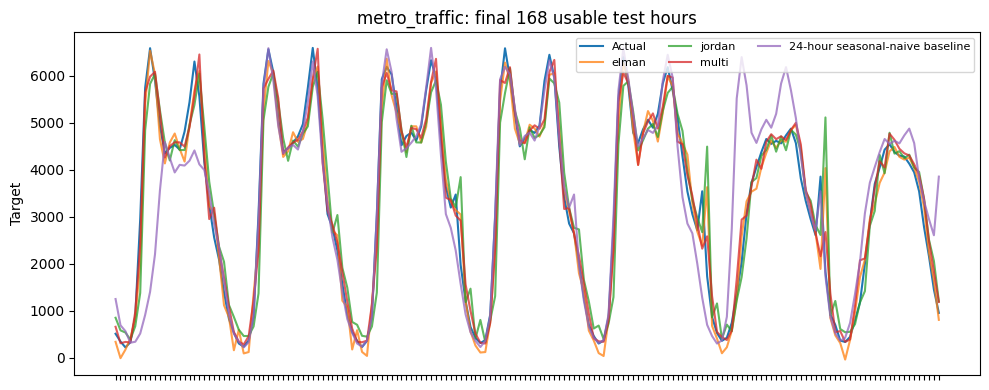

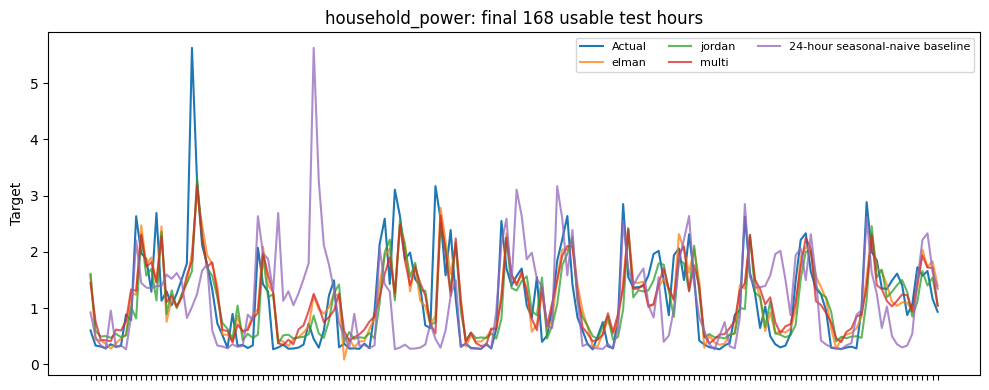

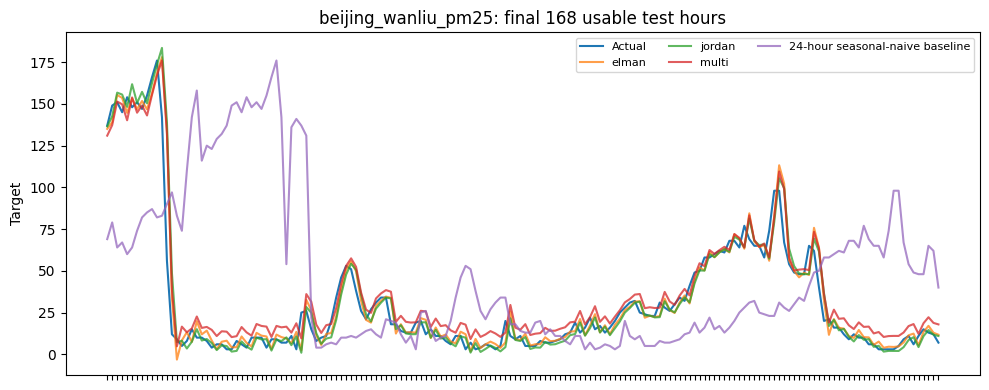

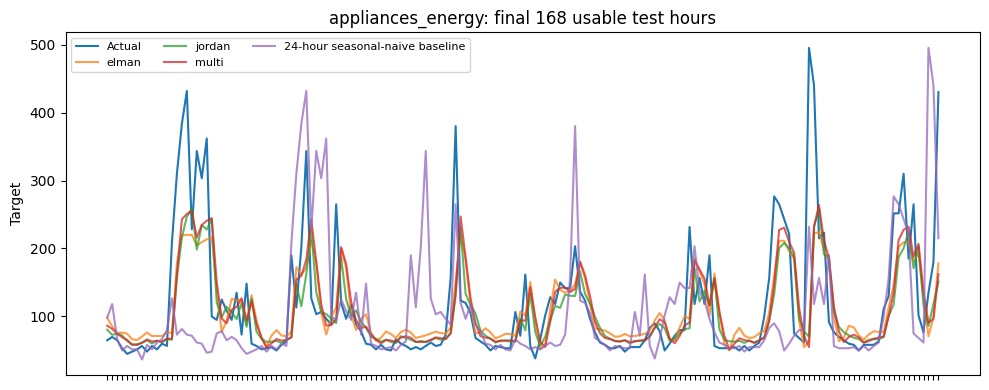

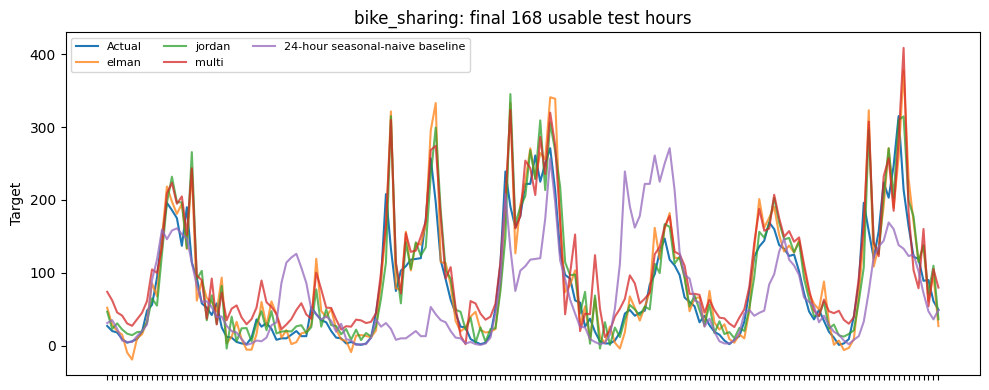

In [13]:
for dataset_name in test_predictions["dataset"].unique():
    subset = test_predictions[
        test_predictions["dataset"] == dataset_name
    ].copy()

    actual = (
        subset
        .drop_duplicates("timestamp")
        .tail(168)
    )

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        actual["timestamp"],
        actual["actual"],
        label="Actual",
        linewidth=1.5,
    )

    for model_name in NETWORKS:
        rows = subset[
            (subset["model"] == model_name)
            & (subset["seed"] == FINAL_SEEDS[0])
        ].tail(168)

        ax.plot(
            rows["timestamp"],
            rows["predicted"],
            label=model_name,
            alpha=0.75,
        )

    baseline = subset[
        subset["model"] == SEASONAL_BASELINE
    ].tail(168)

    ax.plot(
        baseline["timestamp"],
        baseline["predicted"],
        label="24-hour seasonal-naive baseline",
        alpha=0.75,
    )

    ax.set_title(
        f"{dataset_name}: final 168 usable test hours"
    )
    ax.set_ylabel("Target")
    ax.legend(ncol=3, fontsize=8)
    ax.tick_params(axis="x", rotation=30)

    # Avoid showing every hourly timestamp label.
    for label in ax.get_xticklabels():
        label.set_visible(False)

    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{dataset_name}_forecast.png",
        dpi=170,
    )
    plt.show()
    plt.close(fig)


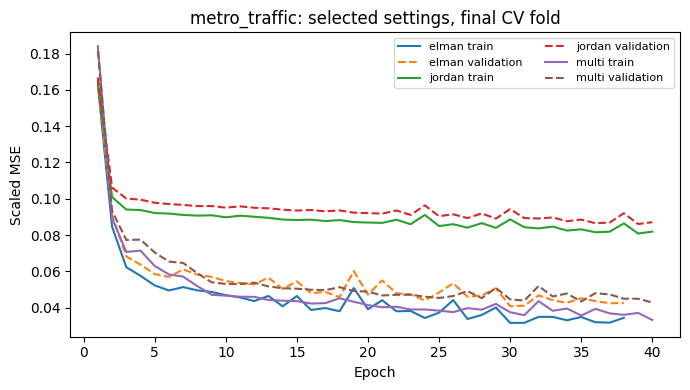

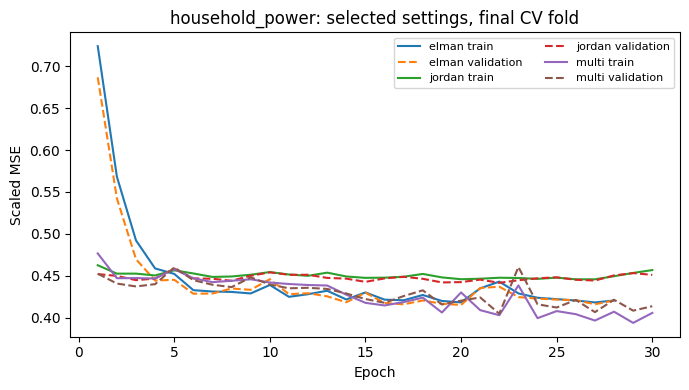

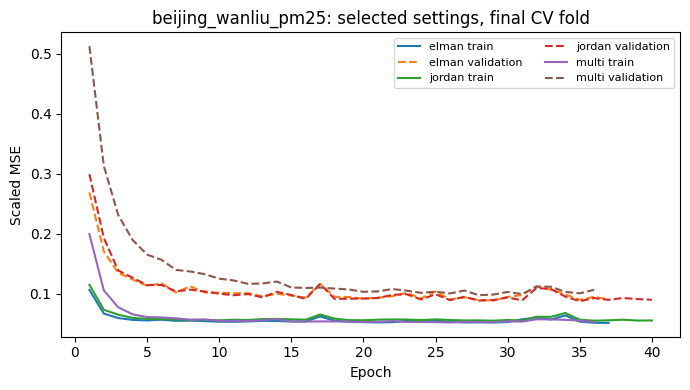

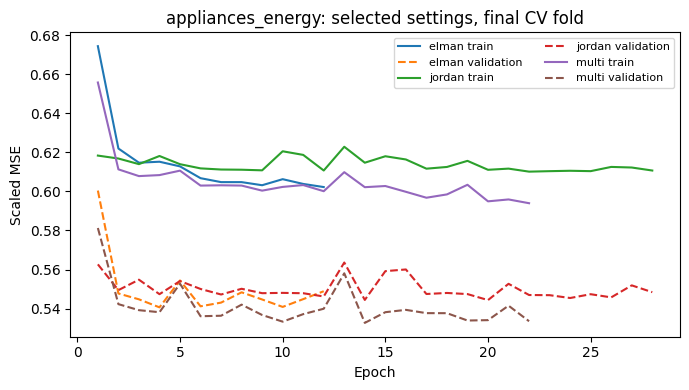

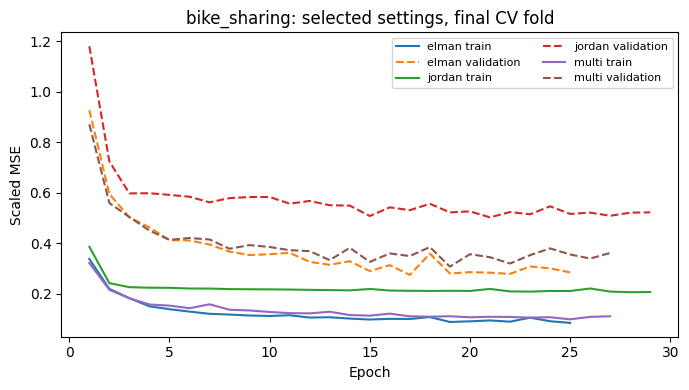

In [14]:
for dataset_name in learning_curves["dataset"].unique():
    fig, ax = plt.subplots(figsize=(7, 4))

    for model_name in NETWORKS:
        rows = learning_curves[
            (learning_curves["dataset"] == dataset_name)
            & (learning_curves["model"] == model_name)
        ]

        ax.plot(
            rows["epoch"],
            rows["train_mse"],
            label=f"{model_name} train",
        )
        ax.plot(
            rows["epoch"],
            rows["val_mse"],
            linestyle="--",
            label=f"{model_name} validation",
        )

    ax.set_title(
        f"{dataset_name}: selected settings, final CV fold"
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Scaled MSE")
    ax.legend(ncol=2, fontsize=8)

    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{dataset_name}_learning.png",
        dpi=170,
    )
    plt.show()
    plt.close(fig)


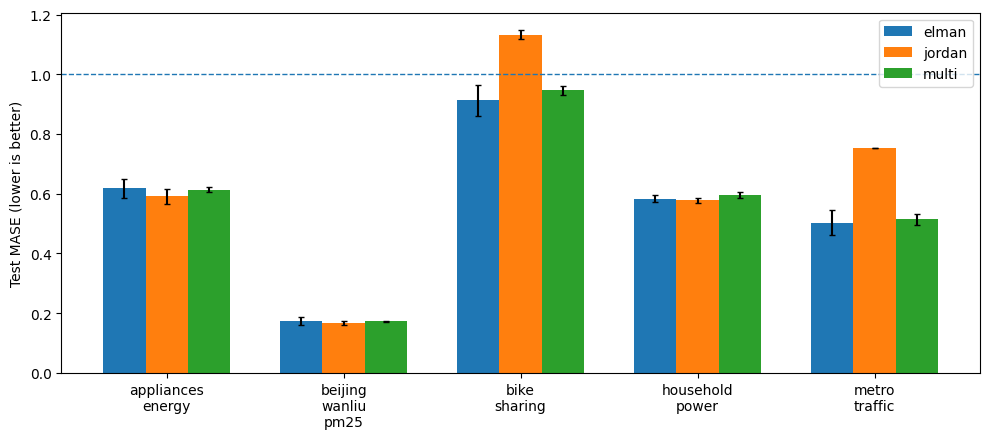

In [15]:
dataset_order = list(
    recurrent_summary["dataset"].drop_duplicates()
)

x = np.arange(len(dataset_order))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 4.5))

for i, model_name in enumerate(NETWORKS):
    rows = (
        recurrent_summary[
            recurrent_summary["model"] == model_name
        ]
        .set_index("dataset")
        .loc[dataset_order]
    )

    ax.bar(
        x + (i - 1) * width,
        rows["mean_mase"],
        width,
        yerr=rows["sd_mase"],
        capsize=2,
        label=model_name,
    )

ax.axhline(1, linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(
    [name.replace("_", "\n") for name in dataset_order]
)
ax.set_ylabel("Test MASE (lower is better)")
ax.legend()

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "aligned_test_mase.png",
    dpi=180,
)
plt.show()
plt.close(fig)


## 14. Save the main results

Only the tables needed to reproduce or discuss the experiment are saved. Forecast and learning-curve figures are already written to the `results/` folder by the cells above.


In [16]:
stationarity_checks = dataset_summary[
    ["dataset", "adf_p", "kpss_p", "stationarity"]
].copy()

dataset_summary.to_csv(OUTPUT_DIR / "dataset_summary.csv", index=False)
stationarity_checks.to_csv(OUTPUT_DIR / "stationarity_checks.csv", index=False)
cv_results.to_csv(OUTPUT_DIR / "cv_results.csv", index=False)
selected_settings.to_csv(OUTPUT_DIR / "selected_settings.csv", index=False)
test_metrics.to_csv(OUTPUT_DIR / "test_metrics.csv", index=False)
model_summary.to_csv(OUTPUT_DIR / "model_summary.csv", index=False)
best_recurrent.to_csv(OUTPUT_DIR / "best_recurrent.csv", index=False)

print("Experiment complete.")
print("Results saved to:", OUTPUT_DIR.resolve())
print("PNG figures:", len(list(OUTPUT_DIR.glob("*.png"))))


Experiment complete.
Results saved to: /home/james/CS741-Assignments/Assignment3/src/results
PNG figures: 21
